# Notebook 2: validation, workflow model and metrics

This notebook reads the SQLite database that the pipeline builds (`data/processed/green_taxi.db`) and
shows the validation results, the data model, the SQL joins and aggregations behind each metric, and
the final evidence. Run `python run_all.py` first.

Everything here is a read-only look at pipeline output. The numbers in `outputs/` come from
`scripts/stage4_metrics.py`, and section 4 checks that this notebook gets the same KPI.

In [1]:
import sqlite3
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
import common as c
from stage4_metrics import MEDIAN_SQL

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
con = sqlite3.connect(c.DB_PATH)
q = lambda sql: pd.read_sql(sql, con)

## 1. Validation rules and what they caught

Each rule has a severity. FAIL means the row is excluded from all metrics. WARN means the trip still
counts but one field is suspect, so it is left out of the metric that uses that field. INFO is recorded
only. No row is deleted: excluded rows stay in `fact_trip` with `status = 'excluded'` and their flags in
`trip_flag`.

In [2]:
q("SELECT rule_id, rule, severity, business_reason, action FROM validation_rule ORDER BY rule_id")

,rule_id,rule,severity,business_reason,action
0,F01,pickup_outside_file_month,FAIL,a monthly KPI must only count trips from that month; also catches clock erro...,excluded from all metrics
1,F02,dropoff_before_pickup,FAIL,"physically impossible, timestamps can't be trusted",excluded from all metrics
2,F03,negative_total_amount,FAIL,these are fare reversals; most copy a real trip with the same times and zone...,excluded from all metrics
3,F04,pickup_zone_not_in_lookup,FAIL,can't place the pickup at all,excluded from all metrics
4,I01,trip_type_missing,INFO,the KPI is about street hails; these trips can't be put in or out of it,"counted as 'unclassified', not in the KPI denominator"
5,I02,passenger_count_missing_or_zero,INFO,"not used by any metric, recorded for the data owner",no action
6,I03,ratecode_missing_or_99,INFO,"not used by any metric, recorded for the data owner",no action
7,W01,zero_duration,WARN,trip may be real but its duration is not,"kept, left out of duration and speed metrics"
8,W02,duration_over_3h,WARN,"almost all are about 23 hours with normal distance and fare, looks like the ...","kept, left out of duration and speed metrics"
9,W03,zero_distance,WARN,meter distance missing or trip cancelled after meter start,"kept, left out of duration and speed metrics"


In [3]:
q('''
SELECT r.rule_id, r.rule, r.severity, COUNT(f.trip_id) AS rows_flagged,
       ROUND(100.0 * COUNT(f.trip_id) / (SELECT COUNT(*) FROM fact_trip), 3) AS pct_of_rows
FROM validation_rule r LEFT JOIN trip_flag f ON f.rule_id = r.rule_id
GROUP BY r.rule_id ORDER BY r.rule_id
''')

,rule_id,rule,severity,rows_flagged,pct_of_rows
0,F01,pickup_outside_file_month,FAIL,205,0.038
1,F02,dropoff_before_pickup,FAIL,8,0.001
2,F03,negative_total_amount,FAIL,1549,0.285
3,F04,pickup_zone_not_in_lookup,FAIL,0,0.000
4,I01,trip_type_missing,INFO,67796,12.482
5,I02,passenger_count_missing_or_zero,INFO,75329,13.869
6,I03,ratecode_missing_or_99,INFO,67796,12.482
7,W01,zero_duration,WARN,416,0.077
8,W02,duration_over_3h,WARN,2279,0.420
9,W03,zero_distance,WARN,17866,3.289


The flags overlap (a zero-distance trip can also be a reversal), so the next query counts trips by status
instead of by flag.

In [4]:
q('''
SELECT file_month, COUNT(*) AS raw_rows,
       SUM(status = 'valid') AS valid, SUM(status = 'excluded') AS excluded,
       SUM(status = 'valid' AND duration_ok = 0) AS valid_but_no_duration_metric
FROM fact_trip GROUP BY file_month ORDER BY file_month
''')

,file_month,raw_rows,valid,excluded,valid_but_no_duration_metric
0,2025-07,48205,48061,144,1901
1,2025-08,46306,46147,159,1871
2,2025-09,48893,48741,152,1744
3,2025-10,49416,49264,152,1941
4,2025-11,46912,46746,166,1817
5,2025-12,48236,48049,187,1937
6,2026-01,40272,40130,142,1521
7,2026-02,37373,37253,120,1624
8,2026-03,44208,44086,122,1736
9,2026-04,44238,44080,158,1884


Month-level checks. These are the gates: any FAIL holds the month, WARN publishes it with a note.

In [5]:
checks = q("SELECT month, stage, \"check\", status, detail FROM month_check")
checks.pivot_table(index="check", columns="status", values="month", aggfunc="count", fill_value=0)

status,INFO,PASS,WARN
check,,,
fail_share_below_limit,0,12,0
no_undocumented_columns,1,11,0
raw_checksum_matches_manifest,0,12,0
raw_equals_valid_plus_excluded,0,12,0
required_columns_present,0,12,0
rows_read_equal_parquet_metadata,0,12,0
vendor_1_reports_to_month_end,0,12,0
vendor_2_reports_to_month_end,0,12,0
vendor_6_reports_to_month_end,0,11,1


In [6]:
checks[checks.status.isin(["WARN", "FAIL", "INFO"])]

,month,stage,check,status,detail
58,2026-06,stage2_validate,no_undocumented_columns,INFO,extra: ['request_source']
116,2026-05,stage3_model,vendor_6_reports_to_month_end,WARN,"4048 valid trips, last pickup date 2026-05-26"


## 2. The workflow model

The business workflow for one green taxi trip is:

request (street hail or dispatch) -> meter on at a pickup zone -> meter off at a dropoff zone -> payment
-> the vendor sends the record to TLC -> TLC publishes the monthly file.

The program team's intervention point is the pickup: that is where the service-area rule applies.
The outcome I measure is where the pickup was (Boro Zone, boundary zone, clearly in the exclusionary
zone, or unknown).

In the database this becomes a small star schema. The grain is the trip record: `fact_trip` has one row
per trip, `dim_zone` gives each pickup and dropoff its service zone and my `zone_class`, `dim_month` holds
what was downloaded, and `trip_flag` links trips to the rules they broke. The events are not separate
records in the source. They come from the timestamps on each trip, so the view `trip_event` turns each trip
into a pickup event and a dropoff event, plus a fare_reversal event for the negative-total rows.
Diagram: `docs/workflow_and_data_model.md`.

In [7]:
tables = ["dim_zone", "dim_month", "fact_trip", "trip_flag", "validation_rule", "api_zone_pickups", "month_check"]
pd.DataFrame({"table": tables, "rows": [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables]})

,table,rows
0,dim_zone,265
1,dim_month,12
2,fact_trip,543143
3,trip_flag,237342
4,validation_rule,13
5,api_zone_pickups,2783
6,month_check,120


In [8]:
q("SELECT event, status, COUNT(*) AS events FROM trip_event GROUP BY event, status ORDER BY event, status")

,event,status,events
0,dropoff,excluded,1759
1,dropoff,valid,541384
2,fare_reversal,excluded,1549
3,pickup,excluded,1759
4,pickup,valid,541384


In [9]:
q("SELECT * FROM trip_event WHERE trip_id = '2025-07-000000' ORDER BY event_ts")

,trip_id,file_month,event,event_ts,location_id,request_mode,status
0,2025-07-000000,2025-07,pickup,2025-07-01 00:48:04,223,street_hail,valid
1,2025-07-000000,2025-07,dropoff,2025-07-01 01:03:36,82,street_hail,valid


In [10]:
q("SELECT zone_class, service_zone, COUNT(*) AS zones FROM dim_zone GROUP BY zone_class, service_zone ORDER BY zone_class")

,zone_class,service_zone,zones
0,boro_zone,Boro Zone,205
1,boundary,Yellow Zone,6
2,clear_hez,Airports,2
3,clear_hez,EWR,1
4,clear_hez,Yellow Zone,49
5,unknown,N/A,2


In [11]:
q("SELECT * FROM fact_trip LIMIT 3").T

,0,1,2
trip_id,2025-07-000000,2025-07-000001,2025-07-000002
file_month,2025-07,2025-07,2025-07
vendor_id,2,2,2
request_mode,street_hail,street_hail,street_hail
request_source,None,None,None
pickup_ts,2025-07-01 00:48:04,2025-07-01 00:37:59,2025-07-01 00:19:15
dropoff_ts,2025-07-01 01:03:36,2025-07-01 01:06:31,2025-07-01 00:33:46
pickup_date,2025-07-01,2025-07-01,2025-07-01
pickup_hour,0,0,0
pu_location_id,223,82,66


Join coverage: every trip must find its pickup and dropoff zone in `dim_zone`, or the KPI would silently
lose rows.

In [12]:
q('''
SELECT COUNT(*) AS trips,
       SUM(pz.location_id IS NOT NULL) AS pickup_joined,
       SUM(dz.location_id IS NOT NULL) AS dropoff_joined
FROM fact_trip t
LEFT JOIN dim_zone pz ON pz.location_id = t.pu_location_id
LEFT JOIN dim_zone dz ON dz.location_id = t.do_location_id
''')

,trips,pickup_joined,dropoff_joined
0,543143,543143,543143


## 3. Joins and aggregations behind the metrics

### Request mode by where the pickup happened (valid trips)

In [13]:
q('''
SELECT z.zone_class,
       SUM(t.request_mode = 'street_hail')  AS street_hail,
       SUM(t.request_mode = 'dispatch')     AS dispatch,
       SUM(t.request_mode = 'unclassified') AS unclassified
FROM fact_trip t JOIN dim_zone z ON z.location_id = t.pu_location_id
WHERE t.status = 'valid'
GROUP BY z.zone_class ORDER BY street_hail DESC
''')

,zone_class,street_hail,dispatch,unclassified
0,boro_zone,416152,25987,59864
1,boundary,29222,61,1106
2,unknown,735,934,79
3,clear_hez,239,264,6741


Dispatch trips are allowed anywhere, and still very few of them start in the Yellow Zone. The
unclassified trips look different: 6,741 of them start clearly inside the exclusionary zone, about 28
times the 239 street hails there. They may be app or dispatch trips, but the data can't tell me. If some
of them were street hails, the KPI would not see them. This is the biggest open question in the project,
so it is metric 4 and the first recommendation in the README.

In [14]:
q('''
SELECT t.vendor_id, COUNT(*) AS unclassified_in_clear_hez
FROM fact_trip t JOIN dim_zone z ON z.location_id = t.pu_location_id
WHERE t.status = 'valid' AND t.request_mode = 'unclassified' AND z.zone_class = 'clear_hez'
GROUP BY t.vendor_id
''')

,vendor_id,unclassified_in_clear_hez
0,1,4
1,2,56
2,6,6681


### The KPI by month

KPI = street hails picked up in the Boro Zone / street hails with a known pickup zone.
Unclassified trips (no trip_type) and pickups in zones 264/265 are not in the denominator, and both are
reported separately so they don't disappear.

In [15]:
kpi = q('''
SELECT t.file_month AS month,
       SUM(z.zone_class <> 'unknown') AS hails_known_zone,
       SUM(z.zone_class = 'boro_zone') AS boro_zone,
       SUM(z.zone_class = 'boundary')  AS boundary,
       SUM(z.zone_class = 'clear_hez') AS clear_hez,
       ROUND(100.0 * SUM(z.zone_class = 'boro_zone') / SUM(z.zone_class <> 'unknown'), 2) AS kpi_pct
FROM fact_trip t JOIN dim_zone z ON z.location_id = t.pu_location_id
WHERE t.status = 'valid' AND t.request_mode = 'street_hail'
GROUP BY t.file_month ORDER BY t.file_month
''')
kpi

,month,hails_known_zone,boro_zone,boundary,clear_hez,kpi_pct
0,2025-07,40237,37397,2817,23,92.94
1,2025-08,37841,35529,2293,19,93.89
2,2025-09,40236,37356,2853,27,92.84
3,2025-10,41654,38660,2974,20,92.81
4,2025-11,38864,36232,2610,22,93.23
5,2025-12,40065,37521,2524,20,93.65
6,2026-01,33042,30834,2195,13,93.32
7,2026-02,30326,28531,1787,8,94.08
8,2026-03,35505,33088,2408,9,93.19
9,2026-04,35762,33365,2382,15,93.30


### Where the non-Boro Zone street hails are

This is the query that changed how I report the KPI. If I just said "100% minus the KPI are violations",
that would be about 6.6% of street hails. But almost all of them are in the six boundary zones.

In [16]:
by_zone = q('''
SELECT z.location_id, z.zone, z.zone_class, COUNT(*) AS street_hails,
       ROUND(100.0 * SUM(dz.service_zone = 'Yellow Zone') / COUNT(*), 1) AS pct_dropoff_yellow_zone,
       ROUND(100.0 * SUM(dz.borough = 'Manhattan' AND dz.service_zone = 'Boro Zone') / COUNT(*), 1) AS pct_dropoff_upper_manhattan
FROM fact_trip t
JOIN dim_zone z  ON z.location_id = t.pu_location_id
JOIN dim_zone dz ON dz.location_id = t.do_location_id
WHERE t.status = 'valid' AND t.request_mode = 'street_hail' AND z.zone_class IN ('boundary', 'clear_hez')
GROUP BY z.location_id ORDER BY street_hails DESC LIMIT 10
''')
by_zone

,location_id,zone,zone_class,street_hails,pct_dropoff_yellow_zone,pct_dropoff_upper_manhattan
0,43,Central Park,boundary,22278,89.3,7.6
1,236,Upper East Side North,boundary,3410,82.3,13.1
2,24,Bloomingdale,boundary,3078,61.0,35.7
3,263,Yorkville West,boundary,393,62.6,28.8
4,132,JFK Airport,clear_hez,116,0.9,0.9
5,138,LaGuardia Airport,clear_hez,89,6.7,2.2
6,262,Yorkville East,boundary,42,45.2,21.4
7,194,Randalls Island,boundary,21,33.3,9.5
8,151,Manhattan Valley,clear_hez,11,100.0,0.0
9,238,Upper West Side North,clear_hez,8,87.5,12.5


In [17]:
q('''
SELECT z.zone_class, COUNT(*) AS street_hails,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_non_boro_hails
FROM fact_trip t JOIN dim_zone z ON z.location_id = t.pu_location_id
WHERE t.status = 'valid' AND t.request_mode = 'street_hail' AND z.zone_class IN ('boundary', 'clear_hez')
GROUP BY z.zone_class
''')

,zone_class,street_hails,pct_of_non_boro_hails
0,boundary,29222,99.19
1,clear_hez,239,0.81


Two things make me careful here:

1. The zone data can't separate a legal pickup on 110th St or 96th St from an illegal one a few blocks
   south, because the boundary zones run right up to the line. So I can't call these violations.
2. The dropoffs don't settle it either. Most Central Park zone hails end in the Yellow Zone (Upper East
   and Upper West Side). That fits a pickup inside the park area, but it also fits a pickup on
   Central Park North (110th St) going south. On top of that, the data dictionary says `trip_type` can be
   changed by the driver, so some of these might be dispatches coded as hails.

So I report the boundary share and the clear share as separate metrics. They can tell TLC which zones and
hours to check first. They are not strong enough to act against individual drivers.

In [18]:
q('''
SELECT dz.zone AS dropoff_zone, dz.service_zone, COUNT(*) AS trips
FROM fact_trip t
JOIN dim_zone dz ON dz.location_id = t.do_location_id
WHERE t.status = 'valid' AND t.request_mode = 'street_hail' AND t.pu_location_id = 43
GROUP BY dz.location_id ORDER BY trips DESC LIMIT 8
''')

,dropoff_zone,service_zone,trips
0,Upper East Side North,Yellow Zone,2929
1,Upper West Side North,Yellow Zone,2619
2,Upper West Side South,Yellow Zone,1558
3,Upper East Side South,Yellow Zone,1454
4,Yorkville West,Yellow Zone,1263
5,Central Park,Yellow Zone,1157
6,Lincoln Square East,Yellow Zone,1057
7,Manhattan Valley,Yellow Zone,946


### Hours of the boundary-zone hails

In [19]:
hours = q('''
SELECT t.pickup_hour AS hour,
       SUM(z.zone_class = 'boundary') AS boundary_hails,
       COUNT(*) AS all_hails,
       ROUND(100.0 * SUM(z.zone_class = 'boundary') / COUNT(*), 2) AS boundary_pct
FROM fact_trip t JOIN dim_zone z ON z.location_id = t.pu_location_id
WHERE t.status = 'valid' AND t.request_mode = 'street_hail'
GROUP BY t.pickup_hour ORDER BY t.pickup_hour
''')
hours.sort_values("boundary_pct", ascending=False).head(6)

,hour,boundary_hails,all_hails,boundary_pct
15,15,2794,31746,8.80
17,17,3209,36997,8.67
16,16,2975,34770,8.56
14,14,2293,28515,8.04
13,13,1942,24846,7.82
12,12,1896,24746,7.66


### Service in the Boro Zone: duration and speed

Median duration and speed for Boro Zone street hails, using only trips with no duration, distance or
speed WARN. I use the median because the 23-hour meter errors would drag a mean around. This is the same
SQL as the pipeline (a `ROW_NUMBER()` window, since SQLite has no median function). It is context, not
one of the 5 metrics.

In [20]:
q(MEDIAN_SQL.format(col="duration_min")).merge(q(MEDIAN_SQL.format(col="speed_mph")), on="month").round(2)

,month,median_duration_min,median_speed_mph
0,2025-07,12.38,10.26
1,2025-08,12.63,10.55
2,2025-09,13.17,9.95
3,2025-10,12.82,9.81
4,2025-11,12.28,10.01
5,2025-12,12.13,9.77
6,2026-01,12.20,9.57
7,2026-02,12.73,9.24
8,2026-03,12.23,9.92
9,2026-04,12.23,9.99


### Cross-check against TLC's published counts

In [21]:
pd.read_csv(ROOT / "outputs" / "api_reconciliation.csv")

,month,raw_rows,raw_rows_known_zone,api_pickups,api_gap_pct,publish_status
0,2025-07,48205,48044,48118,-0.15,OK
1,2025-08,46306,46111,46124,-0.03,OK
2,2025-09,48893,48747,48743,0.01,OK
3,2025-10,49416,49241,49244,-0.01,OK
4,2025-11,46912,46796,46803,-0.01,OK
5,2025-12,48236,48105,48094,0.02,OK
6,2026-01,40272,40142,40141,0.00,OK
7,2026-02,37373,37249,37263,-0.04,OK
8,2026-03,44208,44068,44064,0.01,OK
9,2026-04,44238,44099,44102,-0.01,OK


### Intervention targets

The decision needs a place and a time. This is street hails outside the Boro Zone by zone and hour band,
the same table the pipeline writes to `outputs/intervention_targets.csv`.

In [22]:
pd.read_csv(ROOT / "outputs" / "intervention_targets.csv").head(10)

,zone,location_id,zone_class,hour_band,street_hails,hails_per_week
0,Central Park,43,boundary,15-18,9738,186.8
1,Central Park,43,boundary,11-14,6020,115.5
2,Central Park,43,boundary,19-23,3567,68.4
3,Central Park,43,boundary,07-10,2855,54.8
4,Upper East Side North,236,boundary,15-18,1101,21.1
5,Upper East Side North,236,boundary,07-10,982,18.8
6,Bloomingdale,24,boundary,07-10,965,18.5
7,Upper East Side North,236,boundary,11-14,880,16.9
8,Bloomingdale,24,boundary,11-14,877,16.8
9,Bloomingdale,24,boundary,15-18,744,14.3


## 4. Final metrics and evidence

In [23]:
monthly = pd.read_csv(ROOT / "outputs" / "monthly_metrics.csv")
monthly[["month", "publish_status", "kpi_boro_zone_share_pct", "boundary_hail_pct", "clear_hez_hail_pct",
         "unclassified_pct", "unclassified_clear_hez", "excluded_pct", "triggers_fired"]]

,month,publish_status,kpi_boro_zone_share_pct,boundary_hail_pct,clear_hez_hail_pct,unclassified_pct,unclassified_clear_hez,excluded_pct,triggers_fired
0,2025-07,OK,92.94,7.00,0.06,10.79,477,0.30,NaN
1,2025-08,OK,93.89,6.06,0.05,10.28,375,0.34,NaN
2,2025-09,OK,92.84,7.09,0.07,11.10,489,0.31,NaN
3,2025-10,OK,92.81,7.14,0.05,10.18,517,0.31,NaN
4,2025-11,OK,93.23,6.72,0.06,11.91,616,0.35,NaN
5,2025-12,OK,93.65,6.30,0.05,12.16,585,0.39,NaN
6,2026-01,OK,93.32,6.64,0.04,13.49,522,0.35,NaN
7,2026-02,OK,94.08,5.89,0.03,14.46,464,0.32,NaN
8,2026-03,OK,93.19,6.78,0.03,15.18,679,0.28,unclassified trips above 15.0%: raise with the vendor data team
9,2026-04,OK,93.30,6.66,0.04,14.27,686,0.36,NaN


In [24]:
# the notebook's own SQL KPI should match what the pipeline published
check = kpi.merge(monthly[["month", "kpi_boro_zone_share_pct"]], on="month")
print("notebook KPI == pipeline KPI for every month:", (check.kpi_pct == check.kpi_boro_zone_share_pct).all())

notebook KPI == pipeline KPI for every month: True


In [25]:
display(Markdown((ROOT / "outputs" / "evidence_table.md").read_text()))

# Evidence table: green taxi street hails and the service area

Built by `python run_all.py` from TLC green trip records 2025-07 to 2026-06. Pooled = all published months added up before dividing (12 of 12 months published).

## The 5 metrics

| #       | Metric                                                                                                                            | 2025-07                   | 2026-06                   | Pooled                      | Decision trigger                                                                   |
|:--------|:----------------------------------------------------------------------------------------------------------------------------------|:--------------------------|:--------------------------|:----------------------------|:-----------------------------------------------------------------------------------|
| 1 (KPI) | Street hails picked up in the Boro Zone, % of hails with a known zone                                                             | 92.94%                    | 93.65%                    | 93.39%                      | below 92.0% in a month: review that month's intervention targets                   |
| 2       | Street hails in a boundary Yellow Zone, % of hails                                                                                | 7.00%                     | 6.26%                     | 6.56% (29,222)              | no trigger, used to rank zones and hours                                           |
| 3       | Street hails clearly inside the exclusionary zone or at an airport, % of hails                                                    | 0.06%                     | 0.09%                     | 0.05% (239)                 | above 0.2% in a month: field check at the top clear zones                          |
| 4       | Valid trips with no trip_type (the KPI can't see them), % of valid trips, and how many start clearly inside the exclusionary zone | 10.79% (477 in clear HEZ) | 14.69% (743 in clear HEZ) | 12.52% (6,741 in clear HEZ) | above 15.0%, or over 900 in clear HEZ, in a month: raise with the vendor data team |
| 5       | Raw rows excluded by FAIL rules, % of raw rows                                                                                    | 0.30%                     | 0.28%                     | 0.32%                       | above 2% in a month: month is held and not published                               |

## Context

| Context (not a metric)                            | 2025-07               | 2026-06              | Pooled                 |
|:--------------------------------------------------|:----------------------|:---------------------|:-----------------------|
| Valid green trips per day                         | 1,550                 | 1,468                | 541,384 trips in total |
| File rows vs TLC's published count (API)          | -0.15%                | +0.02%               | see monthly table      |
| Median duration / speed of Boro Zone street hails | 12.38 min / 10.26 mph | 12.58 min / 9.73 mph | 12.50 min / 9.89 mph   |

## Monthly values

| Month   | Status   | 1 KPI %   | 2 Boundary %   | 3 Clear HEZ %   | 4 Unclassified %   | 4 Unclassified in clear HEZ   | 5 Excluded %   | Trips/day   | API gap %   | Triggers fired                                                  |
|:--------|:---------|:----------|:---------------|:----------------|:-------------------|:------------------------------|:---------------|:------------|:------------|:----------------------------------------------------------------|
| 2025-07 | OK       | 92.94     | 7.00           | 0.06            | 10.79              | 477                           | 0.30           | 1,550       | -0.15       | none                                                            |
| 2025-08 | OK       | 93.89     | 6.06           | 0.05            | 10.28              | 375                           | 0.34           | 1,489       | -0.03       | none                                                            |
| 2025-09 | OK       | 92.84     | 7.09           | 0.07            | 11.10              | 489                           | 0.31           | 1,625       | 0.01        | none                                                            |
| 2025-10 | OK       | 92.81     | 7.14           | 0.05            | 10.18              | 517                           | 0.31           | 1,589       | -0.01       | none                                                            |
| 2025-11 | OK       | 93.23     | 6.72           | 0.06            | 11.91              | 616                           | 0.35           | 1,558       | -0.01       | none                                                            |
| 2025-12 | OK       | 93.65     | 6.30           | 0.05            | 12.16              | 585                           | 0.39           | 1,550       | 0.02        | none                                                            |
| 2026-01 | OK       | 93.32     | 6.64           | 0.04            | 13.49              | 522                           | 0.35           | 1,295       | 0.00        | none                                                            |
| 2026-02 | OK       | 94.08     | 5.89           | 0.03            | 14.46              | 464                           | 0.32           | 1,330       | -0.04       | none                                                            |
| 2026-03 | OK       | 93.19     | 6.78           | 0.03            | 15.18              | 679                           | 0.28           | 1,422       | 0.01        | unclassified trips above 15.0%: raise with the vendor data team |
| 2026-04 | OK       | 93.30     | 6.66           | 0.04            | 14.27              | 686                           | 0.36           | 1,469       | -0.01       | none                                                            |
| 2026-05 | WARN     | 94.02     | 5.90           | 0.08            | 12.89              | 588                           | 0.30           | 1,445       | -2.08       | none                                                            |
| 2026-06 | OK       | 93.65     | 6.26           | 0.09            | 14.69              | 743                           | 0.28           | 1,468       | 0.02        | none                                                            |

Status notes:

- 2026-05 (WARN): volume -2.08% vs TLC aggregate; vendor_6_reports_to_month_end (4048 valid trips, last pickup date 2026-05-26)

## Intervention targets: top 10 zone x hour band for street hails outside the Boro Zone

| zone                  |   location_id | zone_class   | hour_band   |   street_hails |   hails_per_week |   % of these hails |
|:----------------------|--------------:|:-------------|:------------|---------------:|-----------------:|-------------------:|
| Central Park          |            43 | boundary     | 15-18       |           9738 |            186.8 |               33.1 |
| Central Park          |            43 | boundary     | 11-14       |           6020 |            115.5 |               20.4 |
| Central Park          |            43 | boundary     | 19-23       |           3567 |             68.4 |               12.1 |
| Central Park          |            43 | boundary     | 07-10       |           2855 |             54.8 |                9.7 |
| Upper East Side North |           236 | boundary     | 15-18       |           1101 |             21.1 |                3.7 |
| Upper East Side North |           236 | boundary     | 07-10       |            982 |             18.8 |                3.3 |
| Bloomingdale          |            24 | boundary     | 07-10       |            965 |             18.5 |                3.3 |
| Upper East Side North |           236 | boundary     | 11-14       |            880 |             16.9 |                3   |
| Bloomingdale          |            24 | boundary     | 11-14       |            877 |             16.8 |                3   |
| Bloomingdale          |            24 | boundary     | 15-18       |            744 |             14.3 |                2.5 |


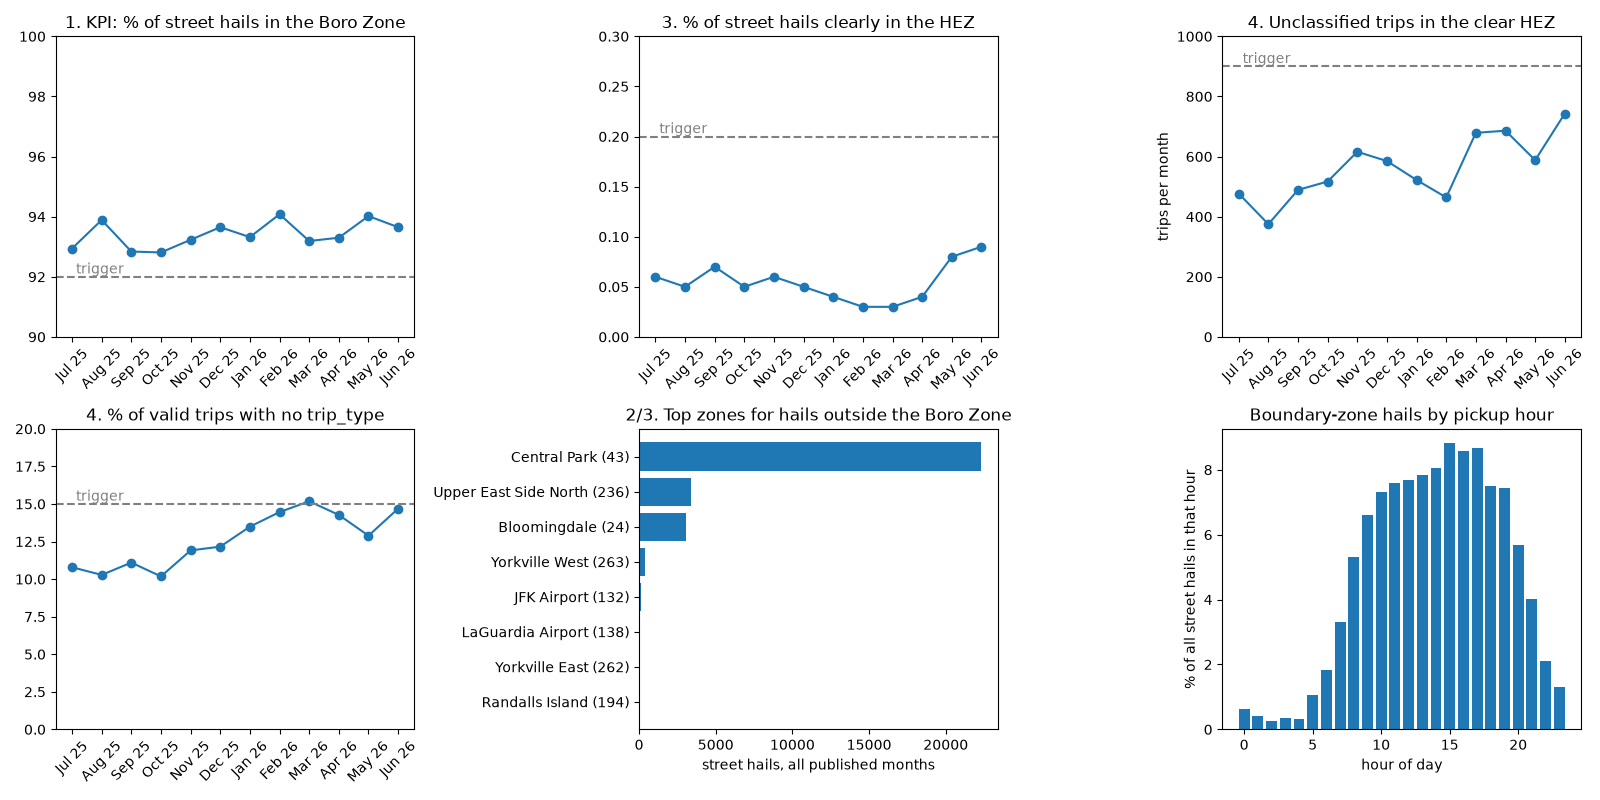

In [26]:
Image(filename=str(ROOT / "outputs" / "dashboard.png"))

## 5. What I conclude

- The KPI is steady at around 93 to 94% of street hails picked up in the Boro Zone, and it never came near
  the 92% trigger.
- Nearly all of the rest are boundary-zone hails, mostly the Central Park zone in the afternoon. Only
  0.05% of street hails are clearly inside the exclusionary zone or at an airport.
- The one trigger that fired is the data one: in March 2026 more than 15% of valid trips had no trip_type.
  Those trips include 6,741 that start clearly inside the exclusionary zone. Getting vendor 6 to report
  trip_type matters more for this KPI than any of the zone findings.
- Volume (about 1,550 trips a day in July 2025, 1,468 in June 2026) is context. It doesn't drive a decision here.

The exact values are in `outputs/evidence_table.md`. Known / Unknown / Assumption / Limitation are in the README.

In [27]:
con.close()